Lists available dataset files under `/kaggle/input` to verify data paths and mounted inputs.

In [1]:
# Input data files are available in the read-only /kaggle/input directory
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/shahdhossam9/transcription-files/transcription-validation.pkl
/kaggle/input/datasets/shahdhossam9/transcription-files/transcription-training.pkl
/kaggle/input/datasets/shahdhossam9/transcription-files/transcription-test.pkl
/kaggle/input/datasets/shahdhossam9/text-features/val_text_features_fasttext.pt
/kaggle/input/datasets/shahdhossam9/text-features/train_text_features_fasttext.pt
/kaggle/input/datasets/shahdhossam9/pipeline-assets2/best_visual_model.pth
/kaggle/input/datasets/shahdhossam9/pipeline-assets2/best_audio_model.pth
/kaggle/input/datasets/shahdhossam9/pipeline-assets2/vocab.json
/kaggle/input/datasets/shahdhossam9/pipeline-assets2/best_text_fasttext_tuned.pth
/kaggle/input/datasets/shahdhossam9/pipeline-assets2/audio_stats.npz
/kaggle/input/datasets/shahdhossam9/video-features/train_visual_features.pt
/kaggle/input/datasets/shahdhossam9/video-features/val_visual_features.pt
/kaggle/input/datasets/shahdhossam9/annotation-files/annotation-training.pkl


Imports core libraries and configures compute/runtime settings for video and audio pipelines (PyTorch, Decord, OpenSMILE, and CUDA options).

In [2]:
!pip install decord -q
!pip install decord opensmile -q
# Standard library
import os
import glob
import pickle
import random
import shutil
import subprocess
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Third-party
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import IterableDataset, DataLoader,TensorDataset
from torchvision import transforms, models
import torchvision.transforms.functional as TF
import decord
from decord import VideoReader, cpu, gpu

# Visualization & Metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

try:
    import opensmile
except ImportError as exc:
    raise ImportError(
        "OpenSMILE Python package is required. Install with: pip install opensmile"
    ) from exc

# Favor torch tensors + GPU decode paths
decord.bridge.set_bridge('torch')
torch.backends.cudnn.benchmark = True
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision('high')
    
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 90.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 23.3 MB/s eta 0:00:00


In [3]:
class PreprocessedTensorDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        # البحث المباشر عن الملفات داخل المسار
        self.files = sorted(glob.glob(os.path.join(root_dir, "*.pt")))
        
        if len(self.files) == 0:
            raise FileNotFoundError(f"No .pt files found in: {root_dir}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        item = torch.load(self.files[idx], map_location="cpu")
        return {"frames": item["frames"], "labels": item["labels"]}

In [4]:
# تعديل المسارات لتشير للمجلد الصحيح الذي يحتوي على الملفات
TRAIN_PATH = "/kaggle/input/datasets/olaragabsaadali/chalearn-train-preprocessed/train_tensors"
VAL_PATH = "/kaggle/input/datasets/olaragabsaadali/chalearn-val-tensors/val_tensors"
# Assuming a test path exists, otherwise we use Val for final metrics demonstration
TEST_PATH = "/kaggle/input/datasets/olaragabsaadali/chalearn-val-tensors/val_tensors" 

print("جاري تحميل بيانات التدريب...")
train_dataset = PreprocessedTensorDataset(root_dir=TRAIN_PATH)
print(f"تم تحميل {len(train_dataset)} عينة تدريب.")

print("جاري تحميل بيانات التحقق...")
val_dataset = PreprocessedTensorDataset(root_dir=VAL_PATH)
print(f"تم تحميل {len(val_dataset)} عينة تحقق.")

print("جاري تحميل بيانات الاختبار...")
test_dataset = PreprocessedTensorDataset(root_dir=TEST_PATH)
print(f"تم تحميل {len(test_dataset)} عينة اختبار.")

جاري تحميل بيانات التدريب...
تم تحميل 9354 عينة تدريب.
جاري تحميل بيانات التحقق...
تم تحميل 5900 عينة تحقق.
جاري تحميل بيانات الاختبار...
تم تحميل 5900 عينة اختبار.


In [57]:
print("جاري فحص ملفات التدريب للتأكد من سلامتها...")
errors = 0
for i in tqdm(range(len(train_dataset)), desc="Checking Train Data"):
    try:
        # محاولة قراءة الملف
        item = train_dataset[i]
        # التأكد من أن الشكل صحيح (يحتوي على frames و labels)
        assert 'frames' in item and 'labels' in item
    except Exception as e:
        print(f"خطأ في الملف رقم {i}: {e}")
        errors += 1

if errors == 0:
    print("✅ كل ملفات التدريب سليمة وقابلة للقراءة!")
else:
    print(f"⚠️ يوجد {errors} ملف تالف.")

جاري فحص ملفات التدريب للتأكد من سلامتها...


Checking Train Data: 100%|██████████| 9354/9354 [02:41<00:00, 57.91it/s]

✅ كل ملفات التدريب سليمة وقابلة للقراءة!


In [5]:
class BellLoss(nn.Module):
    def __init__(self, sigma=9.0, gamma=300.0):
        super().__init__()
        self.sigma = sigma
        self.gamma = gamma

    def forward(self, predictions, targets):
        mse = ((predictions - targets) ** 2) / (2 * self.sigma ** 2)
        bell = self.gamma * (1 - torch.exp(-mse))
        return bell.mean()

class ScheduledCombinedLoss(nn.Module):
    """
    Loss function with scheduled Bell Loss weight
    Bell loss weight increases gradually during warmup epochs
    """
    def __init__(self, warmup_epochs=15, sigma=9.0, gamma=300.0):
        super().__init__()
        self.mae = nn.L1Loss()
        self.mse = nn.MSELoss()
        self.bell = BellLoss(sigma, gamma)
        self.warmup_epochs = warmup_epochs
        self.current_epoch = 0
    
    def set_epoch(self, epoch):
        self.current_epoch = epoch
    
    def forward(self, predictions, targets):
        mae_loss = self.mae(predictions, targets)
        mse_loss = self.mse(predictions, targets)
        
        # Bell loss weight increases with epoch (0 → 1 during warmup)
        alpha = min(1.0, self.current_epoch / self.warmup_epochs)
        bell_loss = self.bell(predictions, targets)
        
        total_loss = mae_loss + mse_loss + alpha * bell_loss
        
        return total_loss, mae_loss, mse_loss, bell_loss

def calculate_racc(sum_abs_error, num_samples):
    """Calculate R_acc = 1 - MAE"""
    if num_samples == 0:
        return 0.0
    return 1.0 - (sum_abs_error / (5.0 * num_samples))

def freeze_subnetwork(model):
    model.eval()
    for param in model.parameters():
        param.requires_grad = False
    return model

def save_checkpoint(model, path):
    model_to_save = model._orig_mod if hasattr(model, "_orig_mod") else model
    torch.save(model_to_save.state_dict(), path)

def load_checkpoint(model, path, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    state_dict = torch.load(path, map_location=device)
    if any(k.startswith("_orig_mod.") for k in state_dict.keys()):
        state_dict = {k.replace("_orig_mod.", "", 1): v for k, v in state_dict.items()}
    model.load_state_dict(state_dict, strict=True)
    return model

print("✅ Loss functions defined")

✅ Loss functions defined


In [6]:
class MetricsTracker:
    """Track and plot training metrics"""
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
        self.val_accuracies = []

    def update(self, train_loss, val_loss, val_acc):
        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)
        self.val_accuracies.append(val_acc)

    def plot(self, title="Training History"):
        epochs = range(1, len(self.train_losses) + 1)
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.train_losses, 'b-', label='Train Loss')
        plt.plot(epochs, self.val_losses, 'r-', label='Val Loss')
        plt.title(f'{title} - Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.val_accuracies, 'g-', label='Val Accuracy (1-MAE)')
        plt.title(f'{title} - Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        
        plt.tight_layout()
        plt.show()

print("✅ MetricsTracker defined")

✅ MetricsTracker defined


## Visual Subnetwork

Defines the visual subnetwork architecture; loss classes (`BellLoss`, `CombinedLoss`) are defined in the previous cell and used during training.

In [ ]:
class VisualSubnetwork(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights="IMAGENET1K_V1")
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.fc_head = nn.Sequential(
            nn.Linear(2048, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.ReLU()
        )
        self.regression_head = nn.Linear(256, 5)

    def forward(self, x):
        bs, n, c, h, w = x.shape
        x = x.view(bs * n, c, h, w)
        f = self.backbone(x).view(bs * n, -1).view(bs, n, -1).mean(1)
        hV = self.fc_head(f)
        return hV, torch.sigmoid(self.regression_head(hV))

print("✅ VisualSubnetwork defined")

Implements visual training utilities, uses class-based `CombinedLoss`, and keeps optimizer/scheduler, validation, checkpointing, and early stopping.

In [ ]:
CROP_SIZE = 128

def resolve_autocast_dtype(device):
    if device.type != 'cuda':
        return torch.float32
    major, _ = torch.cuda.get_device_capability(device)
    return torch.bfloat16 if major >= 8 else torch.float16

def crop_batch(frames, crop_size, center=False):
    b, t, c, h, w = frames.shape
    cropped = torch.empty(b, t, c, crop_size, crop_size, device=frames.device, dtype=frames.dtype)
    
    for idx in range(b):
        if center:
            top = max((h - crop_size) // 2, 0)
            left = max((w - crop_size) // 2, 0)
        else:
            top, left, _, _ = transforms.RandomCrop.get_params(frames[idx, 0], output_size=(crop_size, crop_size))
        cropped[idx] = frames[idx, :, :, top:top + crop_size, left:left + crop_size]
    
    return cropped

def augment_batch(frames):
    for idx in range(frames.shape[0]):
        video = frames[idx]
        if random.random() < 0.5:
            video = TF.hflip(video)
        if random.random() < 0.5:
            video = TF.adjust_brightness(video, random.uniform(0.8, 1.2))
            video = TF.adjust_contrast(video, random.uniform(0.8, 1.2))
            video = TF.adjust_saturation(video, random.uniform(0.8, 1.2))
            video = TF.adjust_hue(video, random.uniform(-0.15, 0.15))
        frames[idx] = video
    return frames

def normalize_batch(frames):
    b, t, c, h, w = frames.shape
    merged = frames.view(b * t, c, h, w)
    merged = TF.normalize(merged, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    return merged.view(b, t, c, h, w)

print("✅ Training utilities defined")

In [ ]:
VISUAL_BEST_PATH = "/kaggle/working/best_visual_model.pth"

def train_visual(
    model,
    train_ds,
    val_ds,
    epochs=80,
    start_epoch=0,
    bs=16,
    patience=8,
    use_amp=True,
    num_workers=2,
    checkpoint_path=VISUAL_BEST_PATH,
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training on: {device}")

    model = model.to(device)
    criterion = ScheduledCombinedLoss(warmup_epochs=15)
    tracker = MetricsTracker()

    if device.type == 'cuda':
        try:
            model = torch.compile(model)
        except:
            pass

    pin_mem = device.type == 'cuda'
    tr_loader = DataLoader(
        train_ds, batch_size=bs, num_workers=num_workers,
        shuffle=True, pin_memory=pin_mem, persistent_workers=num_workers > 0
    )
    val_loader = DataLoader(
        val_ds, batch_size=bs, num_workers=num_workers,
        shuffle=False, pin_memory=pin_mem, persistent_workers=num_workers > 0
    )

    opt = optim.AdamW(model.parameters(), lr=0.001)
    sched = optim.lr_scheduler.LambdaLR(opt, lr_lambda=lambda e: (1 - e / epochs) ** 2)

    amp_enabled = use_amp and device.type == 'cuda'
    autocast_dtype = resolve_autocast_dtype(device)
    scaler = torch.amp.GradScaler(enabled=amp_enabled)

    best_racc = 0.0
    patience_counter = 0

    for ep in range(start_epoch, epochs):
        model.train()
        train_loss_sum = 0.0
        train_batches = 0

        pbar = tqdm(tr_loader, desc=f"Epoch {ep+1}/{epochs} [Train]")
        for batch in pbar:
            frames = batch['frames'].to(device)
            labels = batch['labels'].to(device)

            frames = crop_batch(frames, CROP_SIZE, center=False)
            frames = augment_batch(frames)
            frames = normalize_batch(frames).contiguous()

            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type, enabled=amp_enabled, dtype=autocast_dtype):
                _, preds = model(frames)
                loss, _, _, _ = criterion(preds, labels)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            train_loss_sum += loss.item()
            train_batches += 1

        sched.step()
        avg_train_loss = train_loss_sum / train_batches

        model.eval()
        total_error, total_samples = 0.0, 0
        val_loss_sum, val_batches = 0.0, 0

        with torch.no_grad():
            for batch in val_loader:
                frames = batch['frames'].to(device)
                labels = batch['labels'].to(device)

                frames = crop_batch(frames, CROP_SIZE, center=True)
                frames = normalize_batch(frames).contiguous()

                with torch.amp.autocast(device_type=device.type, enabled=amp_enabled, dtype=autocast_dtype):
                    _, preds = model(frames)
                    loss, _, _, _ = criterion(preds, labels)

                val_loss_sum += loss.item()
                val_batches += 1
                total_error += torch.sum(torch.abs(labels - preds)).item()
                total_samples += labels.size(0)

        avg_val_loss = val_loss_sum / val_batches
        racc = 1.0 - (total_error / (5.0 * total_samples))

        tracker.update(avg_train_loss, avg_val_loss, racc)
        print(f"Epoch {ep+1} -> Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f} | R_acc: {racc:.4f}")

        if racc > best_racc:
            best_racc = racc
            save_checkpoint(model, checkpoint_path)
            patience_counter = 0
            print("✅ Saved best model")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping")
                break

    tracker.plot("Visual Subnetwork")
    return model

print("✅ train_visual defined")

Builds preprocessed visual datasets, trains the visual subnetwork, then freezes its weights for fusion stages.

In [ ]:
TRAIN_PATH = "/kaggle/input/datasets/olaragabsaadali/chalearn-train-preprocessed/train_tensors"
VAL_PATH = "/kaggle/input/datasets/olaragabsaadali/chalearn-val-tensors/val_tensors"

processed_videos_train_ds = PreprocessedTensorDataset(TRAIN_PATH)
processed_videos_val_ds = PreprocessedTensorDataset(VAL_PATH)

print(f"Training samples: {len(processed_videos_train_ds)}")
print(f"Validation samples: {len(processed_videos_val_ds)}")

visual_model = VisualSubnetwork()

train_visual(
    visual_model,
    processed_videos_train_ds,
    processed_videos_val_ds,
    epochs=80,
    start_epoch=0,
    bs=16,
    patience=8,
)

freeze_subnetwork(visual_model)
print("Visual subnetwork frozen.")

In [ ]:
def extract_and_save_features(model, dataset, save_path, split_name):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()
    
    loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)
    
    all_features = []
    all_labels = []
    
    print(f"Extracting features for {split_name}...")
    
    with torch.no_grad():
        for batch in tqdm(loader, desc=split_name):
            frames = batch['frames'].to(device)
            labels = batch['labels']
            
            frames = crop_batch(frames, CROP_SIZE, center=True)
            frames = normalize_batch(frames)
            
            hV, _ = model(frames)
            
            all_features.append(hV.cpu())
            all_labels.append(labels)
    
    final_features = torch.cat(all_features, dim=0)
    final_labels = torch.cat(all_labels, dim=0)
    
    torch.save({'features': final_features, 'labels': final_labels}, save_path)
    print(f"Saved {split_name} features to {save_path}")
    print(f"Feature Shape: {final_features.shape}")

load_checkpoint(visual_model, VISUAL_BEST_PATH)

extract_and_save_features(
    visual_model,
    processed_videos_train_ds,
    "/kaggle/working/train_visual_features.pt",
    "train"
)

extract_and_save_features(
    visual_model,
    processed_videos_val_ds,
    "/kaggle/working/val_visual_features.pt",
    "val"
)

print("All features extracted and saved!")

Defines in-memory acoustic feature extraction with FFmpeg + OpenSMILE eGeMAPS and min-max normalization helpers.

In [ ]:
# Example for later use
data = torch.load("/kaggle/working/train_visual_features.pt")
visual_input = data['features']  # [6000, 256]
labels = data['labels']          # [6000, 5]

In [10]:
AUDIO_SAMPLE_RATE = 44100
EXPECTED_EGEMAPS_DIM = 88

def _assert_ffmpeg_available():
    if shutil.which("ffmpeg") is None:
        raise EnvironmentError("ffmpeg is not available in PATH.")

def extract_audio_signal_ffmpeg(video_path, sample_rate=AUDIO_SAMPLE_RATE):
    cmd = ["ffmpeg", "-v", "error", "-i", str(video_path), "-ac", "1", "-ar", str(sample_rate), 
           "-f", "f32le", "-acodec", "pcm_f32le", "-"]
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    if result.returncode != 0:
        raise RuntimeError(f"FFmpeg failed: {result.stderr.decode()}")
    audio = np.frombuffer(result.stdout, dtype=np.float32)
    if audio.size == 0:
        raise RuntimeError(f"Empty audio extracted from: {video_path}")
    return audio

def build_egemaps_extractor():
    return opensmile.Smile(feature_set=opensmile.FeatureSet.eGeMAPSv02, feature_level=opensmile.FeatureLevel.Functionals)

def extract_egemaps_from_video_map(video_map, annotations, max_items=None, desc="Acoustic eGeMAPS"):
    _assert_ffmpeg_available()
    smile = build_egemaps_extractor()
    keys = list(video_map.keys())
    if max_items is not None:
        keys = keys[:max_items]
    features, labels, video_ids = [], [], []
    failures = 0
    for vid_id in tqdm(keys, desc=desc):
        try:
            video_path = video_map[vid_id]
            audio = extract_audio_signal_ffmpeg(video_path, sample_rate=AUDIO_SAMPLE_RATE)
            feat_df = smile.process_signal(audio, AUDIO_SAMPLE_RATE)
            feat_vec = feat_df.iloc[0].to_numpy(dtype=np.float32)
            features.append(feat_vec)
            labels.append(np.array(annotations[vid_id], dtype=np.float32))
            video_ids.append(vid_id)
        except Exception:
            failures += 1
            continue
    if len(features) == 0:
        raise RuntimeError("No acoustic features were extracted.")
    X = np.stack(features).astype(np.float32)
    y = np.stack(labels).astype(np.float32)
    print(f"{desc} -> processed: {len(X)} | failed: {failures}")
    return X, y, video_ids

def fit_minmax(features):
    mins = features.min(axis=0)
    maxs = features.max(axis=0)
    denom = maxs - mins
    denom[denom == 0] = 1.0
    return mins, denom

def apply_minmax(features, mins, denom):
    return (features - mins) / denom

print("✅ Acoustic extraction functions defined")

In [8]:
def get_video_maps_and_annotations(split, data_root, annotation_root):
    if split == "train":
        annotation_file = "annotation-training.pkl"
    else:
        annotation_file = "annotation-validation.pkl"
    
    annotation_path = os.path.join(annotation_root, annotation_file)
    
    with open(annotation_path, "rb") as f:
        raw_data = pickle.load(f, encoding="latin1")
    
    traits = ['extraversion', 'agreeableness', 'conscientiousness', 'neuroticism', 'openness']
    annotations = {}
    
    for vid_key in raw_data[traits[0]].keys():
        labels = [raw_data[trait][vid_key] for trait in traits]
        annotations[vid_key] = labels
        annotations[os.path.splitext(vid_key)[0]] = labels
        
    video_map = {}
    valid_exts = ('.mp4', '.MP4', '.avi', '.AVI', '.mkv', '.webm')
    
    for ext in valid_exts:
        video_files = glob.glob(os.path.join(data_root, "**", f"*{ext}"), recursive=True)
        for video_path in video_files:
            filename = os.path.basename(video_path)
            filename_no_ext = os.path.splitext(filename)[0]
            if filename in annotations:
                video_map[filename] = video_path
            elif filename_no_ext in annotations:
                video_map[filename_no_ext] = video_path
                
    print(f"Split: {split} | Videos Matched: {len(video_map)}")
    return video_map, annotations

RAW_VIDEO_ROOT = "/kaggle/input/datasets/muhammadwaqas786/first-impressions/first-impressions"
ANNOTATION_ROOT = "/kaggle/input/datasets/shahdhossam9/annotation-files"

class SimpleDataHolder:
    def __init__(self, video_map, annotations):
        self.video_map = video_map
        self.annotations = annotations

train_map, train_anno = get_video_maps_and_annotations("train", RAW_VIDEO_ROOT, ANNOTATION_ROOT)
val_map, val_anno = get_video_maps_and_annotations("validation", RAW_VIDEO_ROOT, ANNOTATION_ROOT)

train_ds = SimpleDataHolder(train_map, train_anno)
val_ds = SimpleDataHolder(val_map, val_anno)

print("تم تجهيز البيانات بنجاح!")

Split: train | Videos Matched: 6000
Split: validation | Videos Matched: 2000
تم تجهيز البيانات بنجاح وجاهز لاستخراج الصوت!


## Builds normalized train/validation acoustic feature matrices from video maps using eGeMAPS.

In [11]:
MAX_AUDIO_ITEMS = None
AUDIO_TRAIN_X, AUDIO_TRAIN_Y, AUDIO_TRAIN_IDS = extract_egemaps_from_video_map(
    video_map=train_ds.video_map,
    annotations=train_ds.annotations,
    max_items=MAX_AUDIO_ITEMS,
    desc="Train Acoustic eGeMAPS",
)
AUDIO_VAL_X, AUDIO_VAL_Y, AUDIO_VAL_IDS = extract_egemaps_from_video_map(
    video_map=val_ds.video_map,
    annotations=val_ds.annotations,
    max_items=MAX_AUDIO_ITEMS,
    desc="Validation Acoustic eGeMAPS",
)

audio_mins, audio_denom = fit_minmax(AUDIO_TRAIN_X)
AUDIO_TRAIN_X = apply_minmax(AUDIO_TRAIN_X, audio_mins, audio_denom).astype(np.float32)
AUDIO_VAL_X = apply_minmax(AUDIO_VAL_X, audio_mins, audio_denom).astype(np.float32)
print("AUDIO_TRAIN_X:", AUDIO_TRAIN_X.shape, "AUDIO_TRAIN_Y:", AUDIO_TRAIN_Y.shape)
print("AUDIO_VAL_X:", AUDIO_VAL_X.shape, "AUDIO_VAL_Y:", AUDIO_VAL_Y.shape)

stats_path = "/kaggle/working/audio_stats.npz"
np.savez(stats_path, mins=audio_mins, denom=audio_denom)
print(f"✅ Audio stats saved to {stats_path}")

Train Acoustic eGeMAPS: 100%|██████████| 6000/6000 [1:58:54<00:00,  1.19s/it]  


Train Acoustic eGeMAPS -> processed: 6000 | failed: 0
Acoustic feature dimension: 88


Validation Acoustic eGeMAPS: 100%|██████████| 2000/2000 [39:39<00:00,  1.19s/it]

Validation Acoustic eGeMAPS -> processed: 2000 | failed: 0
Acoustic feature dimension: 88
AUDIO_TRAIN_X: (6000, 88) AUDIO_TRAIN_Y: (6000, 5)
AUDIO_VAL_X: (2000, 88) AUDIO_VAL_Y: (2000, 5)
Min/Max after normalization (train): 0.0 1.0
✅ Audio stats saved to /kaggle/working/audio_stats.npz


## Defines the acoustic subnetwork

In [ ]:
class AcousticSubnetwork(nn.Module):
    def __init__(self, input_dim, hidden_1=128, hidden_2=256, dropout=0.3):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(input_dim, hidden_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_1, hidden_2),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.regression_head = nn.Linear(hidden_2, 5)
        
    def forward(self, x):
        hA = self.backbone(x)
        preds = torch.sigmoid(self.regression_head(hA))
        return hA, preds

print("✅ AcousticSubnetwork defined")

## Audio Subnetwork Training

In [ ]:
def train_audio_subnetwork(
    train_X,
    train_Y,
    val_X,
    val_Y,
    epochs=100,
    bs=128,
    patience=8,
    lr=1e-3,
    checkpoint_path="/kaggle/working/best_audio_model.pth",
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    criterion = ScheduledCombinedLoss(warmup_epochs=15)
    tracker = MetricsTracker()
    
    train_tensor_ds = torch.utils.data.TensorDataset(torch.from_numpy(train_X), torch.from_numpy(train_Y))
    val_tensor_ds = torch.utils.data.TensorDataset(torch.from_numpy(val_X), torch.from_numpy(val_Y))
    pin_mem = device.type == "cuda"
    train_loader = DataLoader(train_tensor_ds, batch_size=bs, shuffle=True, pin_memory=pin_mem)
    val_loader = DataLoader(val_tensor_ds, batch_size=bs, shuffle=False, pin_memory=pin_mem)
    
    model = AcousticSubnetwork(input_dim=train_X.shape[1]).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    sched = optim.lr_scheduler.LambdaLR(opt, lr_lambda=lambda e: (1 - e / epochs) ** 2)
    best_racc = 0.0
    best_state = None
    patience_counter = 0

    for ep in range(epochs):
        model.train()
        tr_bar = tqdm(train_loader, desc=f"Epoch {ep + 1}/{epochs} [Audio Train]")
        train_loss_sum = 0.0
        for xb, yb in tr_bar:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            _, preds = model(xb)
            loss, _, _, _ = criterion(preds, yb)
            loss.backward()
            opt.step()
            train_loss_sum += loss.item()
            tr_bar.set_postfix({"loss": f"{loss.item():.4f}"})
        avg_train_loss = train_loss_sum / len(train_loader)
        sched.step()
        
        model.eval()
        total_error, total_samples = 0.0, 0
        val_loss_sum = 0.0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                _, preds = model(xb)
                loss, _, _, _ = criterion(preds, yb)
                val_loss_sum += loss.item()
                total_error += torch.sum(torch.abs(yb - preds)).item()
                total_samples += yb.size(0)

        if total_samples > 0:
            racc = 1.0 - (total_error / (5.0 * total_samples))
            avg_val_loss = val_loss_sum / len(val_loader)
            tracker.update(avg_train_loss, avg_val_loss, racc)
            print(f"Epoch {ep + 1} -> Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Audio Val R_acc: {racc:.4f}")
            
            if racc > best_racc:
                best_racc = racc
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                save_checkpoint(model, checkpoint_path)
                print("  -> Saved best audio model")
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print("Early stopping")
                    break
                
    if best_state is not None:
        model.load_state_dict(best_state)
    freeze_subnetwork(model)
    
    print(f"\n✅ Audio training done! Best Val R_acc: {best_racc:.4f}")
    tracker.plot("Audio Subnetwork")
    return model, best_racc

print("✅ train_audio_subnetwork defined")

Trains the acoustic subnetwork, reports best validation `R_acc`, and freezes its weights for fusion stages.

In [ ]:
audio_model, best_audio_racc = train_audio_subnetwork(
    train_X=AUDIO_TRAIN_X,
    train_Y=AUDIO_TRAIN_Y,
    val_X=AUDIO_VAL_X,
    val_Y=AUDIO_VAL_Y,
    epochs=100,
    bs=128,
    patience=8,
    lr=1e-3,
)

In [ ]:
def extract_and_save_audio_features(model, X, Y, save_path, split=""):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()

    x_tensor = torch.from_numpy(X).float()
    y_tensor = torch.from_numpy(Y).float()
    ds = torch.utils.data.TensorDataset(x_tensor, y_tensor)
    loader = DataLoader(ds, batch_size=256, shuffle=False, pin_memory=(device.type == 'cuda'))

    all_feats, all_labels = [], []
    with torch.no_grad():
        for xb, yb in tqdm(loader, desc=f"Extracting {split} audio features"):
            xb = xb.to(device, non_blocking=True)
            hA, _ = model(xb)
            all_feats.append(hA.cpu())
            all_labels.append(yb)

    features = torch.cat(all_feats, dim=0)
    labels = torch.cat(all_labels, dim=0)
    torch.save({"features": features, "labels": labels}, save_path)
    print(f"Saved {split} features -> {save_path}  shape={features.shape}")

load_checkpoint(audio_model, "/kaggle/working/best_audio_model.pth", device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

extract_and_save_audio_features(
    audio_model,
    AUDIO_TRAIN_X,
    AUDIO_TRAIN_Y,
    "/kaggle/working/train_audio_features.pt",
    split="audio-train",
)

extract_and_save_audio_features(
    audio_model,
    AUDIO_VAL_X,
    AUDIO_VAL_Y,
    "/kaggle/working/val_audio_features.pt",
    split="audio-val",
)

print("✅ Audio features extracted!")

# Text Subnetwork
Stage 1 (text branch). Fasttext + Bigru + attention → 256-D representation. Saves `.pt` feature files for downstream fusion.

In [60]:
!pip install gensim spacy -q
!python -m spacy download en_core_web_sm --quiet

import spacy
from collections import Counter
import gensim.downloader as api

try:
    nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])
except OSError:
    print("Downloading spacy model...")
    os.system("python -m spacy download en_core_web_sm --quiet")
    nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

TRAIN_TRANSCRIPT_PATH = "/kaggle/input/datasets/shahdhossam9/transcription-files/transcription-training.pkl"
VAL_TRANSCRIPT_PATH = "/kaggle/input/datasets/shahdhossam9/transcription-files/transcription-validation.pkl"
TRAIN_ANNOTATION_PATH = "/kaggle/input/datasets/shahdhossam9/annotation-files/annotation-training.pkl"
VAL_ANNOTATION_PATH = "/kaggle/input/datasets/shahdhossam9/annotation-files/annotation-validation.pkl"

print("Libraries loaded.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 85.3 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Libraries loaded.


In [61]:
TRAITS = ['extraversion', 'agreeableness', 'conscientiousness', 'neuroticism', 'openness']

FILLERS = {"um", "uh", "ah", "eh", "oh", "mm", "hmm", "like", "you know"}

def preprocess_tokens_advanced(text):
    if not isinstance(text, str): return []
    doc = nlp(text.lower())
    clean_tokens = []
    for tok in doc:
        if not tok.is_alpha: continue
        if tok.text in FILLERS: continue
        clean_tokens.append(tok.lemma_)
    return clean_tokens

def load_pickle_dict(path):
    with open(path, "rb") as f:
        return pickle.load(f, encoding="latin1")

def video_id(key):
    return os.path.splitext(os.path.basename(str(key)))[0]

def load_split(transcript_path, annotation_path):
    transcripts_raw = load_pickle_dict(transcript_path)
    annotations_raw = load_pickle_dict(annotation_path)
    
    transcripts = {video_id(k): str(v) for k, v in transcripts_raw.items()}
    annotations = {}
    for vid_key in annotations_raw[TRAITS[0]].keys():
        annotations[video_id(vid_key)] = [float(annotations_raw[trait][vid_key]) for trait in TRAITS]
    return transcripts, annotations

print("Loading data...")
train_transcripts, train_annotations = load_split(TRAIN_TRANSCRIPT_PATH, TRAIN_ANNOTATION_PATH)
val_transcripts, val_annotations = load_split(VAL_TRANSCRIPT_PATH, VAL_ANNOTATION_PATH)

print("Preprocessing text...")
train_transcript_tokens = {k: preprocess_tokens_advanced(v) for k, v in train_transcripts.items()}
val_transcript_tokens = {k: preprocess_tokens_advanced(v) for k, v in val_transcripts.items()}
print(f"Train samples: {len(train_transcript_tokens)}")

Loading data...
Preprocessing text...
Train samples: 6000


## Preprocessing transcriptions

In [62]:
def build_vocab(token_lists, min_freq=2):
    counter = Counter(tok for tokens in token_lists for tok in tokens)
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(train_transcript_tokens.values())
VOCAB_SIZE = len(vocab)
print(f"Vocabulary size: {VOCAB_SIZE}")

print("Loading FastText vectors...")
ft_model = api.load("fasttext-wiki-news-subwords-300")
print("FastText loaded.")

def build_embedding_matrix(vocab, model, embedding_dim=300):
    matrix = torch.randn(len(vocab), embedding_dim) * 0.01
    matrix[vocab["<PAD>"]] = torch.zeros(embedding_dim)
    found = 0
    
    for word, idx in vocab.items():
        if word in model:
            matrix[idx] = torch.tensor(model[word])
            found += 1
        else:
            try:
                matrix[idx] = torch.tensor(model.get_vector(word))
                found += 1
            except KeyError:
                pass
                
    print(f"FastText coverage: {found}/{len(vocab)} words ({100*found/len(vocab):.1f}%)")
    return matrix

ft_matrix = build_embedding_matrix(vocab, ft_model, embedding_dim=300)

import json
vocab_path = "/kaggle/working/vocab.json"
with open(vocab_path, "w") as f:
    json.dump(vocab, f)
print(f"✅ Vocabulary saved to {vocab_path}")

Vocabulary size: 4772
Loading FastText vectors...
FastText loaded.
FastText coverage: 4672/4772 words (97.9%)
✅ Vocabulary saved to /kaggle/working/vocab.json


## Building Vocabulary matrix

In [63]:
class TranscriptDataset(Dataset):
    def __init__(self, transcript_tokens_dict, annotations_dict, vocab, max_len=80):
        self.pairs = []
        for vid_id, tokens in transcript_tokens_dict.items():
            if vid_id in annotations_dict:
                ids = [vocab.get(t, vocab["<UNK>"]) for t in tokens[:max_len]]
                ids += [vocab["<PAD>"]] * (max_len - len(ids))
                self.pairs.append((ids, annotations_dict[vid_id]))

    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        ids, labels = self.pairs[idx]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(labels, dtype=torch.float32)

class TextSubnetwork(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, padding_idx=0, pretrained_embeddings=None, freeze_embeddings=True, dropout_rate=0.5):
        super().__init__()
        
        self.padding_idx = padding_idx
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)
        self.embedding.weight.requires_grad = not freeze_embeddings

        self.bigru = nn.GRU(input_size=embedding_dim, hidden_size=256, num_layers=1, batch_first=True, bidirectional=True)
        self.layer_norm = nn.LayerNorm(512)
        
        self.attention = nn.Linear(512, 1)
        self.fc = nn.Linear(512, 256)
        self.dropout = nn.Dropout(dropout_rate)
        self.regression_head = nn.Linear(256, 5)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        gru_out, _ = self.bigru(embedded)
        gru_out = self.layer_norm(gru_out)
        
        attn_scores = self.attention(gru_out).squeeze(-1)
        pad_mask = (x != self.padding_idx)
        attn_scores = attn_scores.masked_fill(~pad_mask, -1e9)
        
        attn_weights = torch.softmax(attn_scores, dim=1).unsqueeze(-1)
        attended = torch.sum(attn_weights * gru_out, dim=1)
        
        out = self.dropout(self.fc(attended))
        preds = torch.sigmoid(self.regression_head(out))
        return out, preds

print("✅ TextSubnetwork defined")

✅ TextSubnetwork defined


## Text Subnetwork Architecture (Fasttext + BiGRU + Attention)

## Text Subnetwork Training

In [64]:
def train_text_model_tuned(train_ds, val_ds, pretrained_matrix, epochs=30, bs=64, patience=8):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=bs, shuffle=False, num_workers=2)
    
    model = TextSubnetwork(
        vocab_size=len(vocab), 
        pretrained_embeddings=pretrained_matrix,
        freeze_embeddings=True,
        dropout_rate=0.5
    ).to(device)
    
    criterion = ScheduledCombinedLoss(warmup_epochs=10)
    
    optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    best_val_loss = float('inf')
    patience_counter = 0
    tracker = MetricsTracker()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")
        for tokens, labels in pbar:
            tokens, labels = tokens.to(device), labels.to(device)
            
            optimizer.zero_grad()
            _, preds = model(tokens)
            loss, _, _, _ = criterion(preds, labels)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            total_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})

        model.eval()
        val_loss, total_err, total_n = 0, 0, 0
        
        with torch.no_grad():
            for tokens, labels in val_loader:
                tokens, labels = tokens.to(device), labels.to(device)
                _, preds = model(tokens)
                loss, _, _, _ = criterion(preds, labels)
                
                val_loss += loss.item()
                total_err += torch.sum(torch.abs(labels - preds)).item()
                total_n += labels.size(0)
        
        avg_val_loss = val_loss / len(val_loader)
        racc = calculate_racc(total_err, total_n)
        
        scheduler.step(avg_val_loss)
        
        tracker.update(total_loss/len(train_loader), avg_val_loss, racc)
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1} | LR: {current_lr:.1e} | Val Loss: {avg_val_loss:.4f} | Val R_acc: {racc:.4f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "/kaggle/working/best_text_fasttext_tuned.pth")
            print("  -> Saved best model")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping")
                break
    
    tracker.plot("Text Subnetwork")
    return model

print("✅ train_text_model_tuned defined")

✅ train_text_model_tuned defined


Starting Training...


Epoch 1 [Train]: 100%|██████████| 94/94 [00:02<00:00, 43.45it/s, loss=0.141]


Epoch 1 | LR: 2.0e-04 | Val Loss: 0.1368 | Val R_acc: 0.8835
  -> Saved best model


Epoch 2 [Train]: 100%|██████████| 94/94 [00:01<00:00, 56.22it/s, loss=0.131]


Epoch 2 | LR: 2.0e-04 | Val Loss: 0.1371 | Val R_acc: 0.8833


...

Epoch 23 | LR: 1.0e-04 | Val Loss: 0.1304 | Val R_acc: 0.8890


Epoch 24 [Train]: 100%|██████████| 94/94 [00:01<00:00, 56.90it/s, loss=0.133]


Epoch 24 | LR: 1.0e-04 | Val Loss: 0.1304 | Val R_acc: 0.8890


Epoch 25 [Train]: 100%|██████████| 94/94 [00:01<00:00, 57.48it/s, loss=0.123]


Epoch 25 | LR: 5.0e-05 | Val Loss: 0.1317 | Val R_acc: 0.8882
Early stopping


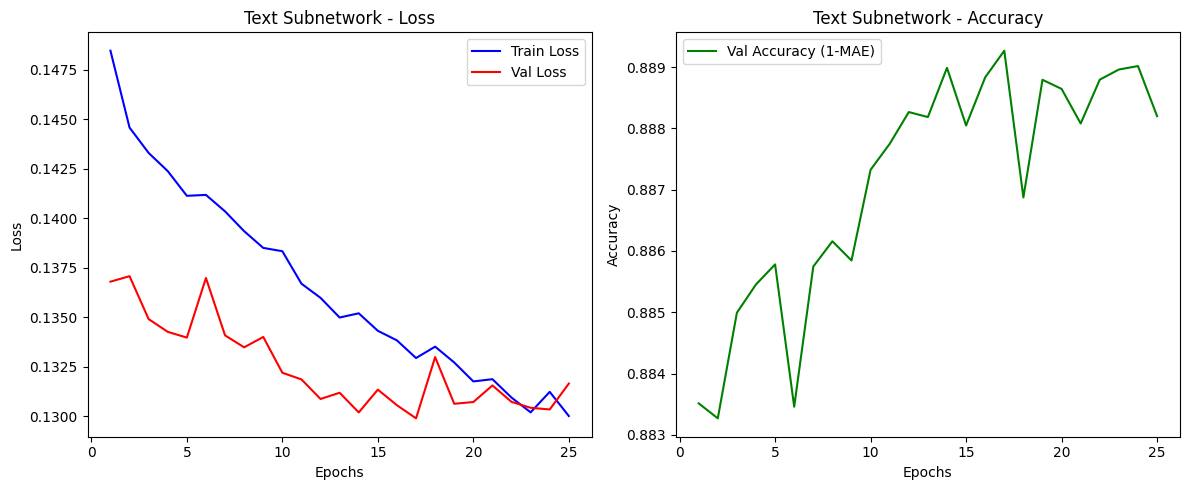

Loading best model...
Best model loaded.


In [65]:
train_tds = TranscriptDataset(train_transcript_tokens, train_annotations, vocab, max_len=80)
val_tds = TranscriptDataset(val_transcript_tokens, val_annotations, vocab, max_len=80)

print("Starting Training...")
text_model = train_text_model_tuned(train_tds, val_tds, pretrained_matrix=ft_matrix)

print("Loading best model...")
text_model.load_state_dict(torch.load("/kaggle/working/best_text_fasttext_tuned.pth"))
print("Best model loaded.")

In [66]:
train_loader_ext = DataLoader(train_tds, batch_size=64, shuffle=False, num_workers=2)
val_loader_ext = DataLoader(val_tds, batch_size=64, shuffle=False, num_workers=2)

def extract_and_save_text_features(model, loader, save_path, split_name=""):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    all_features = []
    all_labels = []
    
    print(f"Extracting features for {split_name}...")
    
    with torch.no_grad():
        for tokens, labels in tqdm(loader, desc=split_name):
            tokens = tokens.to(device)
            hT, _ = model(tokens)
            all_features.append(hT.cpu())
            all_labels.append(labels)
    
    final_features = torch.cat(all_features, dim=0)
    final_labels = torch.cat(all_labels, dim=0)
    
    torch.save({'features': final_features, 'labels': final_labels}, save_path)
    print(f"Saved {split_name} features to {save_path} | Shape: {final_features.shape}")

best_model_path = "/kaggle/working/best_text_fasttext_tuned.pth"

if os.path.exists(best_model_path):
    print("Loading best tuned model...")
    text_model.load_state_dict(torch.load(best_model_path))
    
    extract_and_save_text_features(
        text_model, 
        train_loader_ext,
        "/kaggle/working/train_text_features_fasttext.pt", 
        "text-train"
    )
    
    extract_and_save_text_features(
        text_model, 
        val_loader_ext,
        "/kaggle/working/val_text_features_fasttext.pt", 
        "text-val"
    )
else:
    print("Model file not found. Run training first.")

Loading best tuned model...
Extracting features for text-train...


text-train: 100%|██████████| 94/94 [00:00<00:00, 105.01it/s]


Saved text-train features to /kaggle/working/train_text_features_fasttext.pt | Shape: torch.Size([6000, 256])
Extracting features for text-val...


text-val: 100%|██████████| 32/32 [00:00<00:00, 75.31it/s]

Saved text-val features to /kaggle/working/val_text_features_fasttext.pt | Shape: torch.Size([2000, 256])


## Steps

In [7]:
def get_video_ids(file_path, is_transcript=False):
    with open(file_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")
    
    ids = list(data.keys()) if is_transcript else list(data['extraversion'].keys())
    clean_ids = [os.path.splitext(str(vid))[0] for vid in ids]
    return sorted(list(set(clean_ids)))

print("✅ get_video_ids defined")

✅ get_video_ids defined


In [8]:
def calculate_racc(sum_abs_error, num_samples):
    """
    Calculates the R_acc metric based on Mean Absolute Error.
    Eq 9: R_acc = 1 - (1 / 5N) * sum |y - y_hat|
    """
    if num_samples == 0: 
        return 0.0
    return 1.0 - (sum_abs_error / (5.0 * num_samples))

## Feature Extraction & Save 

# Baseline Model — Stage 2: Multimodal Fusion
Loads the 256-D hidden representations saved by the three subnetwork notebooks, concatenates them, and trains a simple fusion MLP (768 → 512 → 5).

In [68]:
def build_aligned_loader(split_name, annotation_path, transcript_path, bs=64, shuffle=True):
    print(f"Processing {split_name} split...")
    VISUAL_DIR = "/kaggle/working/train_visual_features.pt"
    AUDIO_DIR = "/kaggle/working/train_audio_features.pt"
    TEXT_DIR = "/kaggle/working/train_text_features_fasttext.pt"
    
    if split_name == "val":
        VISUAL_DIR = "/kaggle/working/val_visual_features.pt"
        AUDIO_DIR = "/kaggle/working/val_audio_features.pt"
        TEXT_DIR = "/kaggle/working/val_text_features_fasttext.pt"
    
    vis_ids_src = get_video_ids(annotation_path, is_transcript=False)
    txt_ids_src = get_video_ids(transcript_path, is_transcript=True)
   
    vis_id_to_idx = {vid: i for i, vid in enumerate(vis_ids_src)}
    common_indices = [vis_id_to_idx[vid] for vid in txt_ids_src if vid in vis_id_to_idx]
   
    print(f"Common samples found: {len(common_indices)}")
    if len(common_indices) == 0:
        raise ValueError("No common samples found!")
   
    vis_data = torch.load(VISUAL_DIR, weights_only=False)
    aud_data = torch.load(AUDIO_DIR, weights_only=False)
    txt_data = torch.load(TEXT_DIR, weights_only=False)
   
    vis_feats = vis_data['features'][common_indices]
    aud_feats = aud_data['features'][common_indices]
    txt_feats = txt_data['features'][common_indices]
    labels = aud_data['labels'][common_indices]
   
    assert vis_feats.shape[0] == aud_feats.shape[0] == txt_feats.shape[0] == labels.shape[0]
   
    dataset = TensorDataset(vis_feats, aud_feats, txt_feats, labels)
    return DataLoader(dataset, batch_size=bs, shuffle=shuffle, pin_memory=True, num_workers=2)

print("✅ build_aligned_loader defined")

✅ build_aligned_loader defined


## Baseline Fusion Architecture

In [69]:
def build_fusion_head(input_dim=256 * 3, hidden_dim=512, output_dim=5):
    return nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(hidden_dim, output_dim),
        nn.Sigmoid(),
    )

print("✅ build_fusion_head defined")

✅ build_fusion_head defined


## Stage 2: Baseline Fusion Training

In [70]:
def train_stage2(train_loader, val_loader, epochs=50, lr=1e-3, patience=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    fusion_net = build_fusion_head().to(device)
    criterion = ScheduledCombinedLoss(warmup_epochs=15)
    optimizer = optim.Adam(fusion_net.parameters(), lr=lr)
    tracker = MetricsTracker()
    
    checkpoint_path = "/kaggle/working/best_stage2.pth"
    best_val_acc = 0.0
    patience_counter = 0

    print(f"Training on device: {device}")
    for ep in range(epochs):
        fusion_net.train()
        train_loss_sum = 0.0
        for aud, vis, txt, labels in tqdm(train_loader, desc=f"Ep {ep+1}/{epochs} [Train]", leave=False):
            aud, vis, txt, labels = aud.to(device), vis.to(device), txt.to(device), labels.to(device)
            
            combined = torch.cat([aud, vis, txt], dim=1)
            preds = fusion_net(combined)
            loss, _, _, _ = criterion(preds, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item()
            
        avg_train_loss = train_loss_sum / max(len(train_loader), 1)

        fusion_net.eval()
        val_loss = val_err = n_samples = 0
        with torch.no_grad():
            for aud, vis, txt, labels in val_loader:
                aud, vis, txt, labels = aud.to(device), vis.to(device), txt.to(device), labels.to(device)
                
                combined = torch.cat([aud, vis, txt], dim=1)
                preds = fusion_net(combined)
                loss, _, _, _ = criterion(preds, labels)
                
                val_loss += loss.item()
                val_err += torch.sum(torch.abs(labels - preds)).item()
                n_samples += labels.size(0)

        avg_val_loss = val_loss / max(len(val_loader), 1)
        val_acc = 1.0 - (val_err / (5.0 * n_samples)) if n_samples else 0.0
        
        tracker.update(avg_train_loss, avg_val_loss, val_acc)
        print(f"Epoch {ep+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val R_acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            save_checkpoint(fusion_net, checkpoint_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {ep+1}")
                break

    tracker.plot("Stage 2 Baseline Fusion")
    load_checkpoint(fusion_net, checkpoint_path)
    print(f"Training Complete. Best Val R_acc: {best_val_acc:.4f}")
    return fusion_net

print("✅ train_stage2 defined")

✅ train_stage2 defined


## Run Training

Building DataLoaders...
Processing train split...
Common samples found: 6000
Processing val split...
Common samples found: 2000
Starting Stage 2...
Training on device: cuda


Epoch 01 | Train Loss: 0.1261 | Val Loss: 0.1221 | Val R_acc: 0.8955


Epoch 02 | Train Loss: 0.1214 | Val Loss: 0.1199 | Val R_acc: 0.8973


Epoch 03 | Train Loss: 0.1203 | Val Loss: 0.1228 | Val R_acc: 0.8949


Epoch 04 | Train Loss: 0.1206 | Val Loss: 0.1214 | Val R_acc: 0.8962


...

Epoch 08 | Train Loss: 0.1196 | Val Loss: 0.1210 | Val R_acc: 0.8964


Epoch 09 | Train Loss: 0.1196 | Val Loss: 0.1209 | Val R_acc: 0.8965


Epoch 10 | Train Loss: 0.1185 | Val Loss: 0.1221 | Val R_acc: 0.8955


Epoch 11 | Train Loss: 0.1190 | Val Loss: 0.1208 | Val R_acc: 0.8965


Epoch 12 | Train Loss: 0.1189 | Val Loss: 0.1209 | Val R_acc: 0.8965
Early stopping at epoch 12


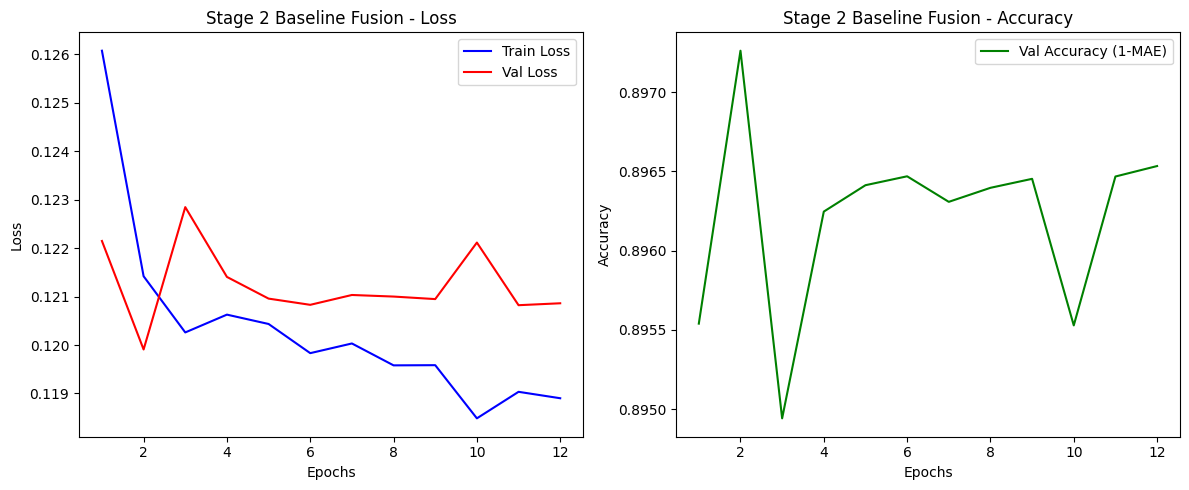

Training Complete. Best Val R_acc: 0.8973


In [71]:
TRAIN_ANNOT_PATH = "/kaggle/input/datasets/shahdhossam9/annotation-files/annotation-training.pkl"
TRAIN_TRANS_PATH = "/kaggle/input/datasets/shahdhossam9/transcription-files/transcription-training.pkl"
VAL_ANNOT_PATH = "/kaggle/input/datasets/shahdhossam9/annotation-files/annotation-validation.pkl"
VAL_TRANS_PATH = "/kaggle/input/datasets/shahdhossam9/transcription-files/transcription-validation.pkl"

print("Building DataLoaders...")
train_loader = build_aligned_loader("train", TRAIN_ANNOT_PATH, TRAIN_TRANS_PATH, bs=64, shuffle=True)
val_loader = build_aligned_loader("val", VAL_ANNOT_PATH, VAL_TRANS_PATH, bs=64, shuffle=False)

print("Starting Stage 2...")
fusion_net = train_stage2(train_loader, val_loader, epochs=50)

# Modified Model — Stages 3 & 4: Siamese Extension + Final Fusion

**Stage 3** — Trains a Siamese projection network (256 → 128-D) for each modality using trait-wise Multi-Similarity loss.  
1. **Stage 4** — 1. 1. 1. 1. Combines M1 baseline features (512-D) with three Siamese embeddings (3 × 128-D = 384-D) → 896-D → final fusion head → 5 trait predictions.1. 

## >>  Personality Class Binning 

In [72]:
class CrossModalExtremeMSLoss(nn.Module):
    def __init__(self, alpha=2.0, beta=50.0, lambda_val=0.5, pos_threshold=0.15):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.lambda_val = lambda_val
        self.pos_threshold = pos_threshold

    def get_positive_mask_soft(self, labels, threshold=None):
        if threshold is None:
            threshold = self.pos_threshold
        diff = torch.abs(labels[:, None] - labels[None, :])
        return diff < threshold

    def get_extreme_mask(self, labels, low_thresh=0.2, high_thresh=0.8):
        return (labels < low_thresh) | (labels > high_thresh)

    def forward(self, embeddings, continuous_labels):
        B = embeddings.size(0)
        if B < 2:
            return torch.tensor(0.0, device=embeddings.device, requires_grad=True)

        embeddings = F.normalize(embeddings, dim=1)
        S = embeddings @ embeddings.t()

        total_loss = torch.tensor(0.0, device=embeddings.device)

        for j in range(5):
            labels_j = continuous_labels[:, j]
            
            extreme_mask = self.get_extreme_mask(labels_j)
            extreme_indices = extreme_mask.nonzero(as_tuple=True)[0]
            
            if len(extreme_indices) < 2:
                continue
            
            sub_embeddings = embeddings[extreme_indices]
            sub_labels = labels_j[extreme_indices]
            sub_B = len(extreme_indices)
            
            sub_S = sub_embeddings @ sub_embeddings.t()
            
            same = self.get_positive_mask_soft(sub_labels)
            eye = torch.eye(sub_B, dtype=torch.bool, device=embeddings.device)
            
            pos_mask = same & ~eye
            neg_mask = (~same) & ~eye
            
            if pos_mask.any():
                pos_term = -self.alpha * (sub_S - self.lambda_val)
                pos_vals = torch.where(pos_mask, pos_term, torch.tensor(-20.0, device=embeddings.device))
                zeros_bias = torch.zeros(sub_B, 1, device=embeddings.device)
                pos_log_sum = torch.logsumexp(torch.cat([zeros_bias, pos_vals], dim=1), dim=1)
                pos_loss = (1.0 / self.alpha) * pos_log_sum
            else:
                pos_loss = torch.zeros(sub_B, device=embeddings.device)
            
            if neg_mask.any():
                neg_term = self.beta * (sub_S - self.lambda_val)
                neg_vals = torch.where(neg_mask, neg_term, torch.tensor(-20.0, device=embeddings.device))
                neg_log_sum = torch.logsumexp(torch.cat([zeros_bias, neg_vals], dim=1), dim=1)
                neg_loss = (1.0 / self.beta) * neg_log_sum
            else:
                neg_loss = torch.zeros(sub_B, device=embeddings.device)
            
            total_loss = total_loss + (pos_loss + neg_loss).sum()
        
        if total_loss == 0:
            return torch.tensor(0.0, device=embeddings.device, requires_grad=True)
        
        return total_loss / (5.0 * B)

print("✅ CrossModalExtremeMSLoss defined")

✅ CrossModalExtremeMSLoss defined


## Siamese Projection Network

In [73]:
class SiameseProjection(nn.Module):
    def __init__(self, input_dim=256, embedding_dim=128, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, embedding_dim),
        )
    
    def forward(self, x):
        return self.net(x)

class MultiModalSiamese(nn.Module):
    def __init__(self, input_dim=256, embedding_dim=128):
        super().__init__()
        self.visual_proj = SiameseProjection(input_dim, embedding_dim)
        self.audio_proj = SiameseProjection(input_dim, embedding_dim)
        self.text_proj = SiameseProjection(input_dim, embedding_dim)
    
    def forward(self, vis, aud, txt):
        eV = self.visual_proj(vis)
        eA = self.audio_proj(aud)
        eT = self.text_proj(txt)
        return eV, eA, eT
    
    def forward_cross(self, vis, aud, txt, labels):
        eV = self.visual_proj(vis)
        eA = self.audio_proj(aud)
        eT = self.text_proj(txt)
        
        mixed_embeddings = torch.stack([eV, eA, eT], dim=1).view(-1, eV.size(-1))
        repeated_labels = labels.repeat_interleave(3, dim=0)
        
        return mixed_embeddings, repeated_labels

print("✅ MultiModalSiamese defined")

✅ MultiModalSiamese defined


## Multi Similarity Loss

## Stage 3: Siamese Network Training

In [74]:
def train_cross_modal_siamese(
    siamese_net,
    train_loader,
    val_loader,
    thresholds=None,
    epochs=100,
    lr=1e-3,
    patience=15,
    checkpoint_path="best_cross_siamese.pth",
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    siamese_net = siamese_net.to(device)
    
    ms_loss_fn = CrossModalExtremeMSLoss()
    optimizer = optim.AdamW(siamese_net.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    best_val_loss = float('inf')
    patience_counter = 0
    
    print(f"Training Cross-Modal Siamese on {device}")
    
    for epoch in range(1, epochs + 1):
        siamese_net.train()
        train_loss = 0.0
        
        for aud, vis, txt, lbl in tqdm(train_loader, desc=f"Epoch {epoch}"):
            aud = aud.to(device)
            vis = vis.to(device)
            txt = txt.to(device)
            lbl = lbl.to(device)
            
            mixed_emb, repeated_labels = siamese_net.forward_cross(vis, aud, txt, lbl)
            loss = ms_loss_fn(mixed_emb, repeated_labels)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(siamese_net.parameters(), 2.0)
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        scheduler.step()
        
        siamese_net.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for aud, vis, txt, lbl in val_loader:
                aud = aud.to(device)
                vis = vis.to(device)
                txt = txt.to(device)
                lbl = lbl.to(device)
                
                mixed_emb, repeated_labels = siamese_net.forward_cross(vis, aud, txt, lbl)
                loss = ms_loss_fn(mixed_emb, repeated_labels)
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        
        print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(siamese_net.state_dict(), checkpoint_path)
            print(f"  ✅ Saved best model (loss: {val_loss:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
    
    siamese_net.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"\n✅ Training complete! Best Val Loss: {best_val_loss:.4f}")
    
    return siamese_net

print("✅ train_cross_modal_siamese defined")

✅ train_cross_modal_siamese defined


## Stage 4: Final Fusion Training

In [75]:
class FinalFusionHead(nn.Module):
    def __init__(self, input_dim=896, hidden_dim=512, output_dim=5, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, output_dim),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.net(x)

print("✅ FinalFusionHead defined")

✅ FinalFusionHead defined


## Run Stages 3

## Run Stages 4

In [76]:
def train_final_fusion_stage4(
    siamese_net,
    baseline_fusion,
    train_loader,
    val_loader,
    epochs=50,
    lr=1e-3,
    patience=10,
    checkpoint_path="best_final_stage4.pth",
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    final_fusion = FinalFusionHead().to(device)
    siamese_net = siamese_net.to(device)
    baseline_fusion = baseline_fusion.to(device)
    
    siamese_net.eval()
    for param in siamese_net.parameters():
        param.requires_grad = False
    
    baseline_fusion.eval()
    for param in baseline_fusion.parameters():
        param.requires_grad = False
    
    optimizer = optim.AdamW(final_fusion.parameters(), lr=lr, weight_decay=1e-5)
    criterion = ScheduledCombinedLoss(warmup_epochs=min(10, epochs//3))
    
    best_val_racc = 0.0
    patience_counter = 0
    
    print(f"Training Stage 4 on {device}")
    
    for epoch in range(1, epochs + 1):
        final_fusion.train()
        criterion.set_epoch(epoch)
        train_loss = 0.0
        
        for aud, vis, txt, lbl in tqdm(train_loader, desc=f"Epoch {epoch}"):
            aud = aud.to(device)
            vis = vis.to(device)
            txt = txt.to(device)
            lbl = lbl.to(device)
            
            with torch.no_grad():
                combined = torch.cat([aud, vis, txt], dim=1)
                m1_hidden = baseline_fusion[0](combined)
                
                eV, eA, eT = siamese_net(vis, aud, txt)
                eV = F.normalize(eV, dim=1)
                eA = F.normalize(eA, dim=1)
                eT = F.normalize(eT, dim=1)
            
            fused = torch.cat([m1_hidden, eV, eA, eT], dim=1)
            preds = final_fusion(fused)
            
            loss, mae, mse, bell = criterion(preds, lbl)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(final_fusion.parameters(), 1.0)
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        
        final_fusion.eval()
        val_loss = 0.0
        total_error = 0.0
        n_samples = 0
        
        with torch.no_grad():
            for aud, vis, txt, lbl in val_loader:
                aud = aud.to(device)
                vis = vis.to(device)
                txt = txt.to(device)
                lbl = lbl.to(device)
                
                combined = torch.cat([aud, vis, txt], dim=1)
                m1_hidden = baseline_fusion[0](combined)
                
                eV, eA, eT = siamese_net(vis, aud, txt)
                eV = F.normalize(eV, dim=1)
                eA = F.normalize(eA, dim=1)
                eT = F.normalize(eT, dim=1)
                
                fused = torch.cat([m1_hidden, eV, eA, eT], dim=1)
                preds = final_fusion(fused)
                
                val_loss += criterion(preds, lbl)[0].item()
                total_error += torch.sum(torch.abs(lbl - preds)).item()
                n_samples += lbl.size(0)
        
        val_loss /= len(val_loader)
        val_racc = 1.0 - (total_error / (5.0 * n_samples)) if n_samples > 0 else 0.0
        
        print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Val R_acc = {val_racc:.4f}")
        
        if val_racc > best_val_racc:
            best_val_racc = val_racc
            patience_counter = 0
            torch.save(final_fusion.state_dict(), checkpoint_path)
            print(f"  ✅ Saved best model (R_acc: {val_racc:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
    
    final_fusion.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"\n✅ Stage 4 Complete! Best Val R_acc: {best_val_racc:.4f}")
    
    return final_fusion, best_val_racc

print("✅ train_final_fusion_stage4 defined")

✅ train_final_fusion_stage4 defined


In [77]:
siamese_net = MultiModalSiamese(input_dim=256, embedding_dim=128)
siamese_net = train_cross_modal_siamese(
    siamese_net=siamese_net,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    lr=1e-3,
    patience=10,
    checkpoint_path="/kaggle/working/best_cross_siamese.pth"
)

Training Cross-Modal Siamese on cuda


Epoch 1: 100%|██████████| 94/94 [00:01<00:00, 49.73it/s]


Epoch 1: Train Loss = 0.0453, Val Loss = 0.0381
  ✅ Saved best model (loss: 0.0381)


Epoch 2: 100%|██████████| 94/94 [00:01<00:00, 56.29it/s]


Epoch 2: Train Loss = 0.0445, Val Loss = 0.0381
  ✅ Saved best model (loss: 0.0381)


...

Epoch 14: Train Loss = 0.0448, Val Loss = 0.0381


Epoch 15: 100%|██████████| 94/94 [00:01<00:00, 55.76it/s]


Epoch 15: Train Loss = 0.0447, Val Loss = 0.0381


Epoch 16: 100%|██████████| 94/94 [00:01<00:00, 54.02it/s]


Epoch 16: Train Loss = 0.0449, Val Loss = 0.0382
Early stopping at epoch 16

✅ Training complete! Best Val Loss: 0.0381


In [78]:
baseline_fusion = build_fusion_head()
load_checkpoint(baseline_fusion, "/kaggle/working/best_stage2.pth")
freeze_subnetwork(baseline_fusion)
baseline_fusion.eval()
print("Baseline fusion loaded and frozen.\n")

final_fusion, best_racc = train_final_fusion_stage4(
    siamese_net=siamese_net,
    baseline_fusion=baseline_fusion,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    lr=1e-3,
    patience=10,
    checkpoint_path="/kaggle/working/best_final_stage4.pth"
)

Baseline fusion loaded and frozen.

Training Stage 4 on cuda


Epoch 1: 100%|██████████| 94/94 [00:00<00:00, 104.97it/s]


Epoch 1: Train Loss = 0.1269, Val Loss = 0.1246, Val R_acc = 0.8960
  ✅ Saved best model (R_acc: 0.8960)


Epoch 2: 100%|██████████| 94/94 [00:00<00:00, 100.11it/s]


Epoch 2: Train Loss = 0.1286, Val Loss = 0.1288, Val R_acc = 0.8955


...

Epoch 13: Train Loss = 0.1511, Val Loss = 0.1523, Val R_acc = 0.8966


Epoch 14: 100%|██████████| 94/94 [00:00<00:00, 99.17it/s] 


Epoch 14: Train Loss = 0.1520, Val Loss = 0.1517, Val R_acc = 0.8969


Epoch 15: 100%|██████████| 94/94 [00:00<00:00, 99.41it/s] 


Epoch 15: Train Loss = 0.1516, Val Loss = 0.1517, Val R_acc = 0.8970
Early stopping at epoch 15

✅ Stage 4 Complete! Best Val R_acc: 0.8971


In [5]:
!pip install opensmile -q
!pip install decord -q  
!pip install opencv-python -q
!pip install spacy -q
!pip install gensim -q
!python -m spacy download en_core_web_sm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 84.0 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 90.2 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can d

In [24]:
# ============================================
# COMPLETE INFERENCE PIPELINE - ORIGINAL (NO CALIBRATION)
# Extracts personality predictions and metrics
# Outputs JSON file for AI analysis
# ============================================

import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import subprocess
import glob
import time
import requests
import cv2
from typing import Dict, Optional, List
import warnings
warnings.filterwarnings("ignore")

# ============================================
# CONFIGURATION
# ============================================

class Config:
    # Model paths
    VISUAL_CKPT = "/kaggle/input/datasets/shahdhossam9/pipeline-assets3/best_visual_model.pth"
    AUDIO_CKPT = "/kaggle/input/datasets/shahdhossam9/pipeline-assets3/best_audio_model.pth"
    TEXT_CKPT = "/kaggle/input/datasets/shahdhossam9/pipeline-assets3/best_text_fasttext_tuned.pth"
    STAGE2_CKPT = "/kaggle/input/datasets/shahdhossam9/pipeline-assets3/best_stage2.pth"
    STAGE3_CKPT = "/kaggle/input/datasets/shahdhossam9/pipeline-assets3/best_cross_siamese.pth"
    STAGE4_CKPT = "/kaggle/input/datasets/shahdhossam9/pipeline-assets3/best_final_stage4.pth"
    VOCAB_PATH = "/kaggle/input/datasets/shahdhossam9/pipeline-assets3/vocab.json"
    AUDIO_STATS_PATH = "/kaggle/input/datasets/shahdhossam9/pipeline-assets3/audio_stats.npz"
    
    # AssemblyAI API Key
    ASSEMBLYAI_API_KEY = "45d18ba3011d4e5697b028cdbe23ebb3"  # استبدلي بمفتاحك
    
    # Processing parameters (NO CALIBRATION)
    MAX_FRAMES = 6
    MAX_TEXT_LEN = 80
    CROP_SIZE = 128
    RESIZE_SIZE = 140
    
    TRAIT_DISPLAY = ["Extraversion", "Agreeableness", "Conscientiousness", "Neuroticism", "Openness"]

config = Config()

# ============================================
# MODEL DEFINITIONS
# ============================================

class SiameseProjection(nn.Module):
    def __init__(self, input_dim=256, embedding_dim=128, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.LayerNorm(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, embedding_dim),
        )
    def forward(self, x): return self.net(x)

class MultiModalSiamese(nn.Module):
    def __init__(self):
        super().__init__()
        self.visual_proj = SiameseProjection()
        self.audio_proj = SiameseProjection()
        self.text_proj = SiameseProjection()
    def forward(self, vis, aud, txt):
        return self.visual_proj(vis), self.audio_proj(aud), self.text_proj(txt)

class FinalFusionHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(896, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 5), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

class VisualSubnetwork(nn.Module):
    def __init__(self):
        super().__init__()
        from torchvision import models
        resnet = models.resnet50(weights=None)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.fc_head = nn.Sequential(
            nn.Linear(2048, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.ReLU()
        )
        self.regression_head = nn.Linear(256, 5)
    def forward(self, x):
        bs, n, c, h, w = x.shape
        x = x.view(bs * n, c, h, w)
        f = self.backbone(x).view(bs * n, -1).view(bs, n, -1).mean(1)
        return self.fc_head(f), torch.sigmoid(self.regression_head(self.fc_head(f)))

class AcousticSubnetwork(nn.Module):
    def __init__(self, input_dim=88):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 256), nn.ReLU(), nn.Dropout(0.3),
        )
        self.regression_head = nn.Linear(256, 5)
    def forward(self, x):
        h = self.backbone(x)
        return h, torch.sigmoid(self.regression_head(h))

class TextSubnetwork(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 300, padding_idx=0)
        self.bigru = nn.GRU(300, 256, 1, batch_first=True, bidirectional=True)
        self.layer_norm = nn.LayerNorm(512)
        self.attention = nn.Linear(512, 1)
        self.fc = nn.Linear(512, 256)
        self.dropout = nn.Dropout(0.5)
        self.regression_head = nn.Linear(256, 5)
    def forward(self, x):
        e = self.dropout(self.embedding(x))
        g, _ = self.bigru(e)
        g = self.layer_norm(g)
        a = self.attention(g).squeeze(-1)
        a = a.masked_fill((x == 0), -1e9)
        w = torch.softmax(a, dim=1).unsqueeze(-1)
        o = torch.sum(w * g, dim=1)
        o = self.dropout(self.fc(o))
        return o, torch.sigmoid(self.regression_head(o))

def build_fusion_head():
    return nn.Sequential(
        nn.Linear(768, 512), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(512, 5), nn.Sigmoid()
    )

# ============================================
# VIDEO FRAME EXTRACTION
# ============================================

def extract_video_frames(video_path, device):
    import torchvision.transforms.functional as TF
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_path}")
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total_frames - 1, config.MAX_FRAMES, dtype=int).tolist()
    
    frames_list = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames_list.append(frame)
        else:
            frames_list.append(np.zeros((224, 224, 3), dtype=np.uint8))
    cap.release()
    
    frames = torch.from_numpy(np.stack(frames_list)).float() / 255.0
    frames = frames.permute(0, 3, 1, 2)
    frames = TF.resize(frames, [config.RESIZE_SIZE, config.RESIZE_SIZE])
    frames = TF.center_crop(frames, [config.CROP_SIZE, config.CROP_SIZE])
    frames = TF.normalize(frames, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    return frames.unsqueeze(0).to(device)

# ============================================
# AUDIO FEATURE EXTRACTION
# ============================================

def extract_audio_features(video_path, device, smile, audio_mins, audio_denom):
    cmd = ["ffmpeg", "-v", "error", "-i", video_path, "-ac", "1", "-ar", "44100", "-f", "f32le", "-"]
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    if result.returncode != 0:
        raise RuntimeError(f"FFmpeg failed")
    audio_data = np.frombuffer(result.stdout, dtype=np.float32)
    if len(audio_data) == 0:
        raise RuntimeError("No audio data")
    feat_df = smile.process_signal(audio_data, 44100)
    audio_feat = feat_df.iloc[0].to_numpy(dtype=np.float32)
    audio_feat = (audio_feat - audio_mins) / (audio_denom + 1e-8)
    return torch.from_numpy(audio_feat).float().unsqueeze(0).to(device)

# ============================================
# ASSEMBLYAI TRANSCRIPTION
# ============================================

def transcribe_with_assemblyai(video_path, api_key):
    if not api_key or api_key == "":
        return ""
    headers = {"authorization": api_key}
    base_url = "https://api.assemblyai.com"
    audio_path = "/tmp/temp_audio.wav"
    cmd = ["ffmpeg", "-v", "error", "-i", video_path, "-ac", "1", "-ar", "16000", audio_path, "-y"]
    subprocess.run(cmd, capture_output=True)
    if not os.path.exists(audio_path):
        return ""
    with open(audio_path, "rb") as f:
        response = requests.post(base_url + "/v2/upload", headers=headers, data=f)
    if response.status_code != 200:
        return ""
    audio_url = response.json().get("upload_url")
    if not audio_url:
        return ""
    data = {
        "audio_url": audio_url,
        "language_detection": True,
        "punctuate": True,
        "speech_models": ["universal-3-pro", "universal-2"]
    }
    response = requests.post(base_url + "/v2/transcript", json=data, headers=headers)
    if response.status_code != 200:
        return ""
    transcript_id = response.json().get('id')
    if not transcript_id:
        return ""
    endpoint = base_url + "/v2/transcript/" + transcript_id
    for _ in range(60):
        result = requests.get(endpoint, headers=headers).json()
        if result.get('status') == 'completed':
            return result.get('text', '')
        elif result.get('status') == 'error':
            return ""
        time.sleep(3)
    return ""

# ============================================
# TEXT PREPROCESSING
# ============================================

def preprocess_text(text, vocab, nlp, max_len=80):
    if not text:
        return torch.zeros(1, max_len, dtype=torch.long)
    FILLERS = {"um", "uh", "ah", "eh", "oh", "mm", "hmm", "like", "you know"}
    doc = nlp(text.lower())
    tokens = []
    for tok in doc:
        if not tok.is_alpha:
            continue
        if tok.text in FILLERS:
            continue
        tokens.append(tok.lemma_)
    ids = [vocab.get(t, vocab.get("<UNK>", 1)) for t in tokens[:max_len]]
    ids += [vocab.get("<PAD>", 0)] * (max_len - len(ids))
    return torch.tensor([ids], dtype=torch.long)

# ============================================
# LOAD CHECKPOINTS
# ============================================

def load_checkpoint(model, path, device):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Checkpoint not found: {path}")
    state_dict = torch.load(path, map_location=device)
    if any(k.startswith("_orig_mod.") for k in state_dict.keys()):
        state_dict = {k.replace("_orig_mod.", "", 1): v for k, v in state_dict.items()}
    model.load_state_dict(state_dict, strict=True)
    model.to(device)
    model.eval()
    return model

def load_vocab(path):
    with open(path, 'r') as f:
        return json.load(f)

# ============================================
# METRICS EXTRACTION
# ============================================

def extract_visual_metrics(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        return None
    face_positions, head_movements, smile_scores, eye_contact_frames = [], [], [], 0
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
    prev_face_center = None
    sample_step = max(1, total_frames // 100)
    processed_frames = 0
    for frame_idx in range(0, total_frames, sample_step):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            continue
        processed_frames += 1
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)
        if len(faces) > 0:
            x, y, w, h = faces[0]
            face_center = (x + w//2, y + h//2)
            face_positions.append(face_center)
            if prev_face_center is not None:
                movement = np.sqrt((face_center[0] - prev_face_center[0])**2 + (face_center[1] - prev_face_center[1])**2)
                head_movements.append(movement)
            prev_face_center = face_center
            roi_gray = gray[y:y+h, x:x+w]
            eyes = eye_cascade.detectMultiScale(roi_gray, 1.1, 5)
            if len(eyes) >= 2:
                eye_contact_frames += 1
            mouth_y = y + int(h * 0.7)
            mouth_h = int(h * 0.2)
            if mouth_y + mouth_h < frame.shape[0]:
                mouth_region = gray[mouth_y:mouth_y+mouth_h, x:x+w]
                avg_intensity = np.mean(mouth_region)
                smile_score = 1.0 if avg_intensity > 180 else avg_intensity / 180
                smile_scores.append(smile_score)
        if processed_frames >= 200:
            break
    cap.release()
    eye_contact_pct = (eye_contact_frames / processed_frames * 100) if processed_frames > 0 else 0
    head_stability = 1.0 - (np.mean(head_movements) / 100.0) if head_movements else 0.5
    smile_freq = np.mean(smile_scores) if smile_scores else 0.3
    return {
        "eye_contact_percentage": round(eye_contact_pct, 1),
        "head_stability_score": round(np.clip(head_stability, 0, 1), 3),
        "smile_frequency": round(smile_freq, 3),
        "face_visibility": round(len(face_positions) / processed_frames if processed_frames > 0 else 0, 3),
        "head_movement_variance": round(np.std(head_movements) if head_movements else 0, 2)
    }

def extract_audio_metrics(video_path):
    try:
        audio_path = "/tmp/temp_audio_analysis.wav"
        cmd = ["ffmpeg", "-v", "error", "-i", video_path, "-ac", "1", "-ar", "16000", audio_path, "-y"]
        subprocess.run(cmd, capture_output=True)
        if not os.path.exists(audio_path):
            return None
        import soundfile as sf
        audio, sr = sf.read(audio_path)
        if len(audio) == 0:
            return None
        duration = len(audio) / sr
        energy = np.abs(audio)
        threshold = np.percentile(energy, 30)
        speech_frames = energy > threshold
        speech_segments = np.diff(np.concatenate(([0], speech_frames.astype(int), [0])))
        speech_starts = np.where(speech_segments == 1)[0]
        speech_ends = np.where(speech_segments == -1)[0]
        if len(audio) > sr:
            zcr = np.mean(np.diff((audio > 0).astype(int)))
            voice_variation = min(1.0, zcr * 10)
        else:
            voice_variation = 0.5
        if len(speech_starts) > 1:
            pauses = speech_starts[1:] - speech_ends[:-1]
            avg_pause = np.mean(pauses) / sr if len(pauses) > 0 else 0
            long_pause_count = len([p for p in pauses if p / sr > 0.5])
        else:
            avg_pause = 0
            long_pause_count = 0
        speaking_rate = (len(audio) / sr) * 120 / duration if duration > 0 else 0
        volume_consistency = 1.0 - np.std(energy) / (np.mean(energy) + 1e-5)
        volume_consistency = max(0, min(1, volume_consistency))
        return {
            "speaking_rate_wpm": round(speaking_rate, 1),
            "volume_consistency": round(volume_consistency, 3),
            "voice_variation_score": round(voice_variation, 3),
            "filler_words_per_minute": 0,
            "avg_pause_duration": round(avg_pause, 2),
            "long_pause_count": long_pause_count,
            "speech_clarity": round(1.0 - (long_pause_count / max(1, len(speech_starts))), 3)
        }
    except Exception as e:
        return None

def extract_text_metrics(transcript):
    if not transcript:
        return None
    sentences = [s.strip() for s in transcript.split('.') if s.strip()]
    words = transcript.split()
    word_count = len(words)
    avg_sentence_len = word_count / max(1, len(sentences))
    unique_words = set(w.lower() for w in words)
    lexical_diversity = len(unique_words) / max(1, word_count)
    confidence_words = ["absolutely", "definitely", "certainly", "confident", "sure", "believe", "know", "guarantee"]
    confidence_count = sum(1 for w in words if w.lower() in confidence_words)
    confidence_score = min(1.0, confidence_count / max(1, word_count) * 20)
    filler_words_set = {"um", "uh", "ah", "eh", "oh", "like", "you know", "actually", "basically", "literally", "so", "well"}
    filler_count = sum(1 for w in words if w.lower() in filler_words_set)
    filler_rate = filler_count / max(1, word_count) * 100
    long_words = [w for w in words if len(w) > 6]
    complexity_score = len(long_words) / max(1, word_count)
    has_intro = any(w.lower() in ["first", "to begin", "initially", "i think"] for w in words[:20])
    has_conclusion = any(w.lower() in ["finally", "in conclusion", "therefore", "so"] for w in words[-20:])
    structure_score = (has_intro + has_conclusion) / 2
    clarity_score = max(0, 1.0 - (filler_rate / 100) - (avg_sentence_len / 200))
    return {
        "word_count": word_count,
        "avg_sentence_length": round(avg_sentence_len, 1),
        "lexical_diversity": round(lexical_diversity, 3),
        "confidence_score": round(confidence_score, 3),
        "filler_word_rate": round(filler_rate, 1),
        "complexity_score": round(complexity_score, 3),
        "structure_score": round(structure_score, 3),
        "clarity_score": round(clarity_score, 3)
    }

# ============================================
# GROUND TRUTH EXTRACTION
# ============================================

def get_ground_truth(video_name):
    """Extract ground truth from ChaLearn annotations"""
    annotation_files = [
        "/kaggle/input/datasets/shahdhossam9/annotation-files/annotation-training.pkl",
        "/kaggle/input/datasets/shahdhossam9/annotation-files/annotation-validation.pkl"
    ]
    traits = ['extraversion', 'agreeableness', 'conscientiousness', 'neuroticism', 'openness']
    video_key = video_name.replace(".mp4", "")
    
    for ann_file in annotation_files:
        if os.path.exists(ann_file):
            with open(ann_file, "rb") as f:
                data = pickle.load(f, encoding="latin1")
            if video_key in data[traits[0]]:
                return {config.TRAIT_DISPLAY[i]: data[trait][video_key] for i, trait in enumerate(traits)}
            if video_name in data[traits[0]]:
                return {config.TRAIT_DISPLAY[i]: data[trait][video_name] for i, trait in enumerate(traits)}
    return None

# ============================================
# LOAD MODELS FUNCTION
# ============================================

def load_all_models(device):
    print(f"\n📌 Loading models on {device}...")
    
    vocab = load_vocab(config.VOCAB_PATH)
    print(f"✅ Vocab: {len(vocab)} words")
    
    import spacy
    try:
        nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])
    except:
        os.system("python -m spacy download en_core_web_sm --quiet")
        nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])
    print("✅ Spacy loaded")
    
    import opensmile
    smile = opensmile.Smile(
        feature_set=opensmile.FeatureSet.eGeMAPSv02,
        feature_level=opensmile.FeatureLevel.Functionals,
    )
    print("✅ OpenSMILE loaded")
    
    stats = np.load(config.AUDIO_STATS_PATH)
    audio_mins, audio_denom = stats['mins'], stats['denom']
    print("✅ Audio stats loaded")
    
    visual = load_checkpoint(VisualSubnetwork(), config.VISUAL_CKPT, device)
    audio = load_checkpoint(AcousticSubnetwork(88), config.AUDIO_CKPT, device)
    text = load_checkpoint(TextSubnetwork(len(vocab)), config.TEXT_CKPT, device)
    baseline = load_checkpoint(build_fusion_head(), config.STAGE2_CKPT, device)
    siamese = load_checkpoint(MultiModalSiamese(), config.STAGE3_CKPT, device)
    final = load_checkpoint(FinalFusionHead(), config.STAGE4_CKPT, device)
    
    print("🎉 ALL MODELS LOADED!\n")
    return vocab, nlp, smile, audio_mins, audio_denom, visual, audio, text, baseline, siamese, final

# ============================================
# PREDICT FUNCTION
# ============================================

def predict_video(video_path, visual, audio, text, baseline, siamese, final, 
                  vocab, nlp, smile, audio_mins, audio_denom, device):
    
    print("🎙️ Transcribing with AssemblyAI...")
    transcript = transcribe_with_assemblyai(video_path, config.ASSEMBLYAI_API_KEY)
    if transcript:
        print(f"📝 Transcript: {transcript[:150]}...")
    else:
        print("⚠️ No transcript available")
    
    print("📹 Extracting video frames...")
    frames = extract_video_frames(video_path, device)
    
    print("🎤 Extracting audio features...")
    audio_tensor = extract_audio_features(video_path, device, smile, audio_mins, audio_denom)
    
    print("📝 Processing text...")
    text_tensor = preprocess_text(transcript or "", vocab, nlp, config.MAX_TEXT_LEN).to(device)
    
    print("🧠 Running inference...")
    with torch.no_grad():
        hV, _ = visual(frames)
        hA, _ = audio(audio_tensor)
        hT, _ = text(text_tensor)
        combined = torch.cat([hA, hV, hT], dim=1)
        m1_hidden = baseline[0](combined)
        eV, eA, eT = siamese(hV, hA, hT)
        eV, eA, eT = F.normalize(eV, dim=1), F.normalize(eA, dim=1), F.normalize(eT, dim=1)
        fused = torch.cat([m1_hidden, eV, eA, eT], dim=1)
        predictions = final(fused)
    
    preds = {config.TRAIT_DISPLAY[i]: float(predictions[0][i]) for i in range(5)}
    return preds, transcript

# ============================================
# MAIN FUNCTION
# ============================================

def main():
    print("=" * 60)
    print("🔮 PERSONALITY PREDICTION PIPELINE (ORIGINAL - NO CALIBRATION)")
    print("=" * 60)
    print("⚠️ This pipeline uses the original model without calibration")
    print("=" * 60)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Load models
    vocab, nlp, smile, audio_mins, audio_denom, visual, audio, text, baseline, siamese, final = load_all_models(device)
    
    # Get video path
    video_paths = glob.glob("/kaggle/input/datasets/shahdhossam9/test-videos/13kjwEtSyXc.003.mp4")
    
    if not video_paths:
        print("⚠️ No videos found!")
        return
    
    # Process all videos
    all_results = []
    
    for video_path in video_paths:
        video_name = os.path.basename(video_path)
        print("\n" + "=" * 60)
        print(f"📹 Processing: {video_name}")
        print("=" * 60)
        
        try:
            # Get predictions and transcript
            predictions, transcript = predict_video(
                video_path, visual, audio, text, baseline, siamese, final,
                vocab, nlp, smile, audio_mins, audio_denom, device
            )
            
            # Extract metrics
            print("📊 Extracting metrics...")
            visual_metrics = extract_visual_metrics(video_path)
            audio_metrics = extract_audio_metrics(video_path)
            text_metrics = extract_text_metrics(transcript)
            ground_truth = get_ground_truth(video_name)
            
            # Calculate errors if ground truth available
            errors = None
            if ground_truth:
                errors = {trait: predictions[trait] - ground_truth[trait] for trait in config.TRAIT_DISPLAY}
            
            # Prepare result
            result = {
                "video_name": video_name,
                "predictions": predictions,
                "visual_metrics": visual_metrics,
                "audio_metrics": audio_metrics,
                "text_metrics": text_metrics,
                "transcript": transcript if transcript else None,
                "has_ground_truth": ground_truth is not None
            }
            
            if ground_truth:
                result["ground_truth"] = ground_truth
                result["errors"] = errors
            
            all_results.append(result)
            
            # Display summary
            print(f"\n🎯 PREDICTIONS for {video_name}:")
            for trait, score in predictions.items():
                bar = "█" * int(score * 30) + "░" * (30 - int(score * 30))
                print(f"  {trait}: {score:.3f} {bar}")
            
            if ground_truth:
                print(f"\n📊 Comparison with Ground Truth:")
                for trait in config.TRAIT_DISPLAY:
                    diff = predictions[trait] - ground_truth[trait]
                    arrow = "↑" if diff > 0 else "↓"
                    print(f"  {trait}: GT={ground_truth[trait]:.3f} | Pred={predictions[trait]:.3f} | {arrow} {abs(diff):.3f}")
            
        except Exception as e:
            print(f"❌ Error processing {video_name}: {e}")
            all_results.append({
                "video_name": video_name,
                "error": str(e)
            })
    
    # Save all results to JSON
    output_path = "/kaggle/working/personality_predictions.json"
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(all_results, f, indent=2, ensure_ascii=False)
    
    print("\n" + "=" * 60)
    print(f"✅ Results saved to: {output_path}")
    print("=" * 60)
    print("\n📋 JSON file ready for AI analysis!")
    print("   You can copy and paste the content to ChatGPT/Claude/Gemini")

if __name__ == "__main__":
    import pickle
    main()

🔮 PERSONALITY PREDICTION PIPELINE (ORIGINAL - NO CALIBRATION)
⚠️ This pipeline uses the original model without calibration

📌 Loading models on cuda...
✅ Vocab: 4772 words
✅ Spacy loaded
✅ OpenSMILE loaded
✅ Audio stats loaded
🎉 ALL MODELS LOADED!


📹 Processing: 13kjwEtSyXc.003.mp4
🎙️ Transcribing with AssemblyAI...
📝 Transcript: working. I've been answering emails for the last few hours and I still have a lot of editing to do. I still have to work out today, but I did my Blog ...
📹 Extracting video frames...
🎤 Extracting audio features...
📝 Processing text...
🧠 Running inference...
📊 Extracting metrics...

🎯 PREDICTIONS for 13kjwEtSyXc.003.mp4:
  Extraversion: 0.466 █████████████░░░░░░░░░░░░░░░░░
  Agreeableness: 0.553 ████████████████░░░░░░░░░░░░░░
  Conscientiousness: 0.520 ███████████████░░░░░░░░░░░░░░░
  Neuroticism: 0.517 ███████████████░░░░░░░░░░░░░░░
  Openness: 0.552 ████████████████░░░░░░░░░░░░░░

✅ Results saved to: /kaggle/working/personality_predictions.json

📋 JSON file 